In [52]:
# Univariant 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.io as pio

In [2]:
dataset=pd.read_csv("Lead_Scoring_Regression.csv")

In [3]:
dataset

,Lead_ID,Lead_Source,Industry,Total_Visits,Time_Spent_Website,Page_Views,Email_Opens,Email_Clicks,Previous_Interactions,Lead_Quality_Score,Age,Annual_Income,Sales_Calls,Days_Since_Last_Activity,Estimated_Lead_Value
0,10001,Website,IT,4.0,1408.0,4.93,11.0,6,12,20.66,43,65285.0,13,93,76395.09
1,10002,Referral,Manufacturing,3.0,514.0,6.95,15.0,9,15,78.89,41,91555.0,2,69,103479.70
2,10003,LinkedIn,Finance,13.0,NaN,13.09,13.0,2,0,32.17,33,142713.0,2,117,72876.96
3,10004,Referral,Healthcare,23.0,73.0,8.57,15.0,4,5,92.98,57,57471.0,3,9,104055.36
4,10005,Referral,Finance,9.0,600.0,1.13,7.0,6,12,91.42,46,73671.0,8,126,104722.27
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1785,11796,Website,Education,13.0,1159.0,9.11,14.0,7,10,80.53,39,NaN,1,68,112770.55
1786,11797,Email,Retail,30.0,1428.0,13.33,0.0,6,7,44.76,49,30037.0,5,171,84872.35
1787,11798,Google,Manufacturing,7.0,727.0,14.82,15.0,1,6,93.77,30,85526.0,12,73,111880.49
1788,11799,Facebook,Healthcare,26.0,1152.0,13.04,4.0,0,7,72.54,32,NaN,11,6,129093.92


In [4]:
dataset = dataset.drop('Lead_ID', axis=1, errors='ignore')
dataset

,Lead_Source,Industry,Total_Visits,Time_Spent_Website,Page_Views,Email_Opens,Email_Clicks,Previous_Interactions,Lead_Quality_Score,Age,Annual_Income,Sales_Calls,Days_Since_Last_Activity,Estimated_Lead_Value
0,Website,IT,4.0,1408.0,4.93,11.0,6,12,20.66,43,65285.0,13,93,76395.09
1,Referral,Manufacturing,3.0,514.0,6.95,15.0,9,15,78.89,41,91555.0,2,69,103479.70
2,LinkedIn,Finance,13.0,NaN,13.09,13.0,2,0,32.17,33,142713.0,2,117,72876.96
3,Referral,Healthcare,23.0,73.0,8.57,15.0,4,5,92.98,57,57471.0,3,9,104055.36
4,Referral,Finance,9.0,600.0,1.13,7.0,6,12,91.42,46,73671.0,8,126,104722.27
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1785,Website,Education,13.0,1159.0,9.11,14.0,7,10,80.53,39,NaN,1,68,112770.55
1786,Email,Retail,30.0,1428.0,13.33,0.0,6,7,44.76,49,30037.0,5,171,84872.35
1787,Google,Manufacturing,7.0,727.0,14.82,15.0,1,6,93.77,30,85526.0,12,73,111880.49
1788,Facebook,Healthcare,26.0,1152.0,13.04,4.0,0,7,72.54,32,NaN,11,6,129093.92


In [5]:
independent = dataset.drop('Estimated_Lead_Value', axis=1)

In [6]:
independent

,Lead_Source,Industry,Total_Visits,Time_Spent_Website,Page_Views,Email_Opens,Email_Clicks,Previous_Interactions,Lead_Quality_Score,Age,Annual_Income,Sales_Calls,Days_Since_Last_Activity
0,Website,IT,4.0,1408.0,4.93,11.0,6,12,20.66,43,65285.0,13,93
1,Referral,Manufacturing,3.0,514.0,6.95,15.0,9,15,78.89,41,91555.0,2,69
2,LinkedIn,Finance,13.0,NaN,13.09,13.0,2,0,32.17,33,142713.0,2,117
3,Referral,Healthcare,23.0,73.0,8.57,15.0,4,5,92.98,57,57471.0,3,9
4,Referral,Finance,9.0,600.0,1.13,7.0,6,12,91.42,46,73671.0,8,126
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1785,Website,Education,13.0,1159.0,9.11,14.0,7,10,80.53,39,NaN,1,68
1786,Email,Retail,30.0,1428.0,13.33,0.0,6,7,44.76,49,30037.0,5,171
1787,Google,Manufacturing,7.0,727.0,14.82,15.0,1,6,93.77,30,85526.0,12,73
1788,Facebook,Healthcare,26.0,1152.0,13.04,4.0,0,7,72.54,32,NaN,11,6


In [7]:
dependent = dataset['Estimated_Lead_Value']

In [8]:
dependent

0        76395.09
1       103479.70
2        72876.96
3       104055.36
4       104722.27
          ...    
1785    112770.55
1786     84872.35
1787    111880.49
1788    129093.92
1789     96272.33
Name: Estimated_Lead_Value, Length: 1790, dtype: float64

In [9]:
def quanQual(dataset):
    quan = []
    qual = []

    for column in dataset.columns:
        if dataset[column].dtype == 'object':
            qual.append(column)
        else:
            quan.append(column)

    return quan, qual

In [10]:
quan, qual = quanQual(independent)

In [11]:
print("Quantitative columns:")
print(quan)

print("\nQualitative columns:")
print(qual)

Quantitative columns:
['Total_Visits', 'Time_Spent_Website', 'Page_Views', 'Email_Opens', 'Email_Clicks', 'Previous_Interactions', 'Lead_Quality_Score', 'Age', 'Annual_Income', 'Sales_Calls', 'Days_Since_Last_Activity']

Qualitative columns:
['Lead_Source', 'Industry']


In [12]:
independent = pd.get_dummies(
    independent,
    columns=qual,
    drop_first=True,
    dtype=int
)

In [13]:
independent

,Total_Visits,Time_Spent_Website,Page_Views,Email_Opens,Email_Clicks,Previous_Interactions,Lead_Quality_Score,Age,Annual_Income,Sales_Calls,...,Lead_Source_Facebook,Lead_Source_Google,Lead_Source_LinkedIn,Lead_Source_Referral,Lead_Source_Website,Industry_Finance,Industry_Healthcare,Industry_IT,Industry_Manufacturing,Industry_Retail
0,4.0,1408.0,4.93,11.0,6,12,20.66,43,65285.0,13,...,0,0,0,0,1,0,0,1,0,0
1,3.0,514.0,6.95,15.0,9,15,78.89,41,91555.0,2,...,0,0,0,1,0,0,0,0,1,0
2,13.0,NaN,13.09,13.0,2,0,32.17,33,142713.0,2,...,0,0,1,0,0,1,0,0,0,0
3,23.0,73.0,8.57,15.0,4,5,92.98,57,57471.0,3,...,0,0,0,1,0,0,1,0,0,0
4,9.0,600.0,1.13,7.0,6,12,91.42,46,73671.0,8,...,0,0,0,1,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1785,13.0,1159.0,9.11,14.0,7,10,80.53,39,NaN,1,...,0,0,0,0,1,0,0,0,0,0
1786,30.0,1428.0,13.33,0.0,6,7,44.76,49,30037.0,5,...,0,0,0,0,0,0,0,0,0,1
1787,7.0,727.0,14.82,15.0,1,6,93.77,30,85526.0,12,...,0,1,0,0,0,0,0,0,1,0
1788,26.0,1152.0,13.04,4.0,0,7,72.54,32,NaN,11,...,1,0,0,0,0,0,1,0,0,0


In [14]:
descriptive=pd.DataFrame()

In [15]:
descriptive = pd.DataFrame(index=["Mean", "Median", "Mode"], columns=quan)

for columnName in quan:
    descriptive.loc["Mean", columnName] = dataset[columnName].mean()
    descriptive.loc["Median", columnName] = dataset[columnName].median()
    descriptive.loc["Mode", columnName] = dataset[columnName].mode()[0]

In [16]:
descriptive

,Total_Visits,Time_Spent_Website,Page_Views,Email_Opens,Email_Clicks,Previous_Interactions,Lead_Quality_Score,Age,Annual_Income,Sales_Calls,Days_Since_Last_Activity
Mean,15.606838,778.788034,10.395721,9.956125,5.07486,7.558659,60.528001,39.796648,87643.717379,7.560894,90.165922
Median,16.0,791.0,10.45,10.0,5.0,8.0,60.515,40.0,86829.0,7.0,90.0
Mode,17.0,1290.0,5.19,0.0,6,15,58.02,35,53688.0,15,179


In [17]:
descriptive = pd.DataFrame(index=["Mean", "Median", "Mode","Q1:25%","Q2:50%","Q3:75%","Q4:100%"], columns=quan)
for columnName in quan:
    descriptive.loc["Mean", columnName] = dataset[columnName].mean()
    descriptive.loc["Median", columnName] = dataset[columnName].median()
    descriptive.loc["Mode", columnName] = dataset[columnName].mode()[0]
    descriptive.loc["Q1:25%", columnName] = dataset.describe()[columnName]["25%"]
    descriptive.loc["Q2:50%", columnName] = dataset.describe()[columnName]["50%"]
    descriptive.loc["Q3:75%", columnName] = dataset.describe()[columnName]["75%"]
    descriptive.loc["Q4:100%", columnName] = dataset.describe()[columnName]["max"]

In [18]:
descriptive

,Total_Visits,Time_Spent_Website,Page_Views,Email_Opens,Email_Clicks,Previous_Interactions,Lead_Quality_Score,Age,Annual_Income,Sales_Calls,Days_Since_Last_Activity
Mean,15.606838,778.788034,10.395721,9.956125,5.07486,7.558659,60.528001,39.796648,87643.717379,7.560894,90.165922
Median,16.0,791.0,10.45,10.0,5.0,8.0,60.515,40.0,86829.0,7.0,90.0
Mode,17.0,1290.0,5.19,0.0,6,15,58.02,35,53688.0,15,179
Q1:25%,8.0,413.5,5.585,5.0,2.0,4.0,40.63,29.0,56989.5,4.0,46.0
Q2:50%,16.0,791.0,10.45,10.0,5.0,8.0,60.515,40.0,86829.0,7.0,90.0
Q3:75%,23.0,1146.0,15.145,15.0,8.0,12.0,80.6075,50.0,119277.0,12.0,135.0
Q4:100%,30.0,1499.0,20.0,20.0,10.0,15.0,99.97,60.0,150000.0,15.0,180.0


In [19]:
descriptive = pd.DataFrame(index=["Mean", "Median", "Mode","Q1:25%","Q2:50%","Q3:75%","Q4:100%","IQR","1.5rule","Lesser","Greater","Min","Max"],columns=quan)
for columnName in quan:
    descriptive.loc["Mean", columnName] = dataset[columnName].mean()
    descriptive.loc["Median", columnName] = dataset[columnName].median()
    descriptive.loc["Mode", columnName] = dataset[columnName].mode()[0]
    descriptive.loc["Q1:25%", columnName] = dataset.describe()[columnName]["25%"]
    descriptive.loc["Q2:50%", columnName] = dataset.describe()[columnName]["50%"]
    descriptive.loc["Q3:75%", columnName] = dataset.describe()[columnName]["75%"]
    descriptive.loc["Q4:100%", columnName] = dataset.describe()[columnName]["max"]
    descriptive.loc["IQR", columnName] = descriptive.loc["Q3:75%", columnName]-descriptive.loc["Q1:25%", columnName]
    descriptive.loc["1.5rule", columnName] = 1.5*descriptive.loc["IQR", columnName]
    descriptive.loc["Lesser", columnName] = descriptive.loc["Q1:25%", columnName]-1.5*descriptive.loc["IQR", columnName]
    descriptive.loc["Greater", columnName] = descriptive.loc["Q3:75%", columnName]+1.5*descriptive.loc["IQR", columnName]
    descriptive.loc["Min", columnName] = dataset[columnName].min()
    descriptive.loc["Max", columnName] = dataset[columnName].max()

In [20]:
descriptive

,Total_Visits,Time_Spent_Website,Page_Views,Email_Opens,Email_Clicks,Previous_Interactions,Lead_Quality_Score,Age,Annual_Income,Sales_Calls,Days_Since_Last_Activity
Mean,15.606838,778.788034,10.395721,9.956125,5.07486,7.558659,60.528001,39.796648,87643.717379,7.560894,90.165922
Median,16.0,791.0,10.45,10.0,5.0,8.0,60.515,40.0,86829.0,7.0,90.0
Mode,17.0,1290.0,5.19,0.0,6,15,58.02,35,53688.0,15,179
Q1:25%,8.0,413.5,5.585,5.0,2.0,4.0,40.63,29.0,56989.5,4.0,46.0
Q2:50%,16.0,791.0,10.45,10.0,5.0,8.0,60.515,40.0,86829.0,7.0,90.0
Q3:75%,23.0,1146.0,15.145,15.0,8.0,12.0,80.6075,50.0,119277.0,12.0,135.0
Q4:100%,30.0,1499.0,20.0,20.0,10.0,15.0,99.97,60.0,150000.0,15.0,180.0
IQR,15.0,732.5,9.56,10.0,6.0,8.0,39.9775,21.0,62287.5,8.0,89.0
1.5rule,22.5,1098.75,14.34,15.0,9.0,12.0,59.96625,31.5,93431.25,12.0,133.5
Lesser,-14.5,-685.25,-8.755,-10.0,-7.0,-8.0,-19.33625,-2.5,-36441.75,-8.0,-87.5


In [21]:
lesser=[]
greater=[]

for columnName in quan:
    if(descriptive[columnName]["Min"]<descriptive[columnName]["Lesser"]):
       lesser.append(columnName)
    if(descriptive[columnName]["Max"]>descriptive[columnName]["Greater"]):
       greater.append(columnName)

In [22]:
lesser

[]

In [23]:
greater

[]

In [24]:
for columnName in lesser:
    dataset.loc[dataset[columnName] < descriptive.loc["Lesser", columnName],columnName] = descriptive.loc["Lesser", columnName]
for columnName in greater:
    dataset.loc[dataset[columnName] > descriptive.loc["Greater", columnName],columnName] = descriptive.loc["Greater", columnName]

In [25]:
descriptive = pd.DataFrame(index=["Mean", "Median", "Mode","Q1:25%","Q2:50%","Q3:75%","Q4:100%","IQR","1.5rule","Lesser","Greater","Min","Max"],columns=quan)
for columnName in quan:
    descriptive.loc["Mean", columnName] = dataset[columnName].mean()
    descriptive.loc["Median", columnName] = dataset[columnName].median()
    descriptive.loc["Mode", columnName] = dataset[columnName].mode()[0]
    descriptive.loc["Q1:25%", columnName] = dataset.describe()[columnName]["25%"]
    descriptive.loc["Q2:50%", columnName] = dataset.describe()[columnName]["50%"]
    descriptive.loc["Q3:75%", columnName] = dataset.describe()[columnName]["75%"]
    descriptive.loc["Q4:100%", columnName] = dataset.describe()[columnName]["max"]
    descriptive.loc["IQR", columnName] = descriptive.loc["Q3:75%", columnName]-descriptive.loc["Q1:25%", columnName]
    descriptive.loc["1.5rule", columnName] = 1.5*descriptive.loc["IQR", columnName]
    descriptive.loc["Lesser", columnName] = descriptive.loc["Q1:25%", columnName]-1.5*descriptive.loc["IQR", columnName]
    descriptive.loc["Greater", columnName] = descriptive.loc["Q3:75%", columnName]+1.5*descriptive.loc["IQR", columnName]
    descriptive.loc["Min", columnName] = dataset[columnName].min()
    descriptive.loc["Max", columnName] = dataset[columnName].max()

In [26]:
descriptive

,Total_Visits,Time_Spent_Website,Page_Views,Email_Opens,Email_Clicks,Previous_Interactions,Lead_Quality_Score,Age,Annual_Income,Sales_Calls,Days_Since_Last_Activity
Mean,15.606838,778.788034,10.395721,9.956125,5.07486,7.558659,60.528001,39.796648,87643.717379,7.560894,90.165922
Median,16.0,791.0,10.45,10.0,5.0,8.0,60.515,40.0,86829.0,7.0,90.0
Mode,17.0,1290.0,5.19,0.0,6,15,58.02,35,53688.0,15,179
Q1:25%,8.0,413.5,5.585,5.0,2.0,4.0,40.63,29.0,56989.5,4.0,46.0
Q2:50%,16.0,791.0,10.45,10.0,5.0,8.0,60.515,40.0,86829.0,7.0,90.0
Q3:75%,23.0,1146.0,15.145,15.0,8.0,12.0,80.6075,50.0,119277.0,12.0,135.0
Q4:100%,30.0,1499.0,20.0,20.0,10.0,15.0,99.97,60.0,150000.0,15.0,180.0
IQR,15.0,732.5,9.56,10.0,6.0,8.0,39.9775,21.0,62287.5,8.0,89.0
1.5rule,22.5,1098.75,14.34,15.0,9.0,12.0,59.96625,31.5,93431.25,12.0,133.5
Lesser,-14.5,-685.25,-8.755,-10.0,-7.0,-8.0,-19.33625,-2.5,-36441.75,-8.0,-87.5


In [27]:
lesser=[]
greater=[]

for columnName in quan:
    if(descriptive[columnName]["Lesser"]>descriptive[columnName]["Min"]):
        lesser.append(columnName)
    if(descriptive[columnName]["Greater"]<descriptive[columnName]["Max"]):
        greater.append(columnName)

In [28]:
lesser

[]

In [29]:
greater

[]

In [30]:
freqTable=pd.DataFrame(columns=["Unique_Values","Frequency","Relative Frequency","Cusum"])

In [31]:
freqTable

,Unique_Values,Frequency,Relative Frequency,Cusum


In [32]:
freqTable["Unique_Values"]=dataset["Lead_Quality_Score"].value_counts().index
freqTable["Frequency"]=dataset["Lead_Quality_Score"].value_counts().values
freqTable["Relative Frequency"]=(freqTable["Frequency"]/103)
freqTable["Cusum"]=freqTable["Relative Frequency"].cumsum()

In [33]:
freqTable

,Unique_Values,Frequency,Relative Frequency,Cusum
0,58.02,4,0.038835,0.038835
1,21.62,3,0.029126,0.067961
2,90.00,3,0.029126,0.097087
3,88.64,3,0.029126,0.126214
4,88.24,3,0.029126,0.155340
...,...,...,...,...
1576,95.61,1,0.009709,17.009709
1577,91.54,1,0.009709,17.019417
1578,65.75,1,0.009709,17.029126
1579,41.24,1,0.009709,17.038835


In [34]:
def Univariate(dataset,quan):
    descriptive = pd.DataFrame(index=["Mean", "Median", "Mode","Q1:25%","Q2:50%","Q3:75%","Q4:100%","IQR","1.5rule","Lesser","Greater","Min","Max"],columns=quan)
    for columnName in quan:
    
        descriptive.loc["Mean", columnName] = dataset[columnName].mean()
        descriptive.loc["Median", columnName] = dataset[columnName].median()
        descriptive.loc["Mode", columnName] = dataset[columnName].mode()[0]
        descriptive.loc["Q1:25%", columnName] = dataset.describe()[columnName]["25%"]
        descriptive.loc["Q2:50%", columnName] = dataset.describe()[columnName]["50%"]
        descriptive.loc["Q3:75%", columnName] = dataset.describe()[columnName]["75%"]
        descriptive.loc["Q4:100%", columnName] = dataset.describe()[columnName]["max"]
        descriptive.loc["IQR", columnName] = descriptive.loc["Q3:75%", columnName]-descriptive.loc["Q1:25%", columnName]
        descriptive.loc["1.5rule", columnName] = 1.5*descriptive.loc["IQR", columnName]
        descriptive.loc["Lesser", columnName] = descriptive.loc["Q1:25%", columnName]-1.5*descriptive.loc["IQR", columnName]
        descriptive.loc["Greater", columnName] = descriptive.loc["Q3:75%", columnName]+1.5*descriptive.loc["IQR", columnName]
        descriptive.loc["Min", columnName] = dataset[columnName].min()
        descriptive.loc["Max", columnName] = dataset[columnName].max()      
    
    return descriptive

In [35]:
Univariate(dataset,quan)

,Total_Visits,Time_Spent_Website,Page_Views,Email_Opens,Email_Clicks,Previous_Interactions,Lead_Quality_Score,Age,Annual_Income,Sales_Calls,Days_Since_Last_Activity
Mean,15.606838,778.788034,10.395721,9.956125,5.07486,7.558659,60.528001,39.796648,87643.717379,7.560894,90.165922
Median,16.0,791.0,10.45,10.0,5.0,8.0,60.515,40.0,86829.0,7.0,90.0
Mode,17.0,1290.0,5.19,0.0,6,15,58.02,35,53688.0,15,179
Q1:25%,8.0,413.5,5.585,5.0,2.0,4.0,40.63,29.0,56989.5,4.0,46.0
Q2:50%,16.0,791.0,10.45,10.0,5.0,8.0,60.515,40.0,86829.0,7.0,90.0
Q3:75%,23.0,1146.0,15.145,15.0,8.0,12.0,80.6075,50.0,119277.0,12.0,135.0
Q4:100%,30.0,1499.0,20.0,20.0,10.0,15.0,99.97,60.0,150000.0,15.0,180.0
IQR,15.0,732.5,9.56,10.0,6.0,8.0,39.9775,21.0,62287.5,8.0,89.0
1.5rule,22.5,1098.75,14.34,15.0,9.0,12.0,59.96625,31.5,93431.25,12.0,133.5
Lesser,-14.5,-685.25,-8.755,-10.0,-7.0,-8.0,-19.33625,-2.5,-36441.75,-8.0,-87.5


In [36]:
def Univariate(dataset,quan):
    descriptive = pd.DataFrame(index=["Mean", "Median", "Mode","Q1:25%","Q2:50%","Q3:75%","Q4:100%","IQR","1.5rule","Lesser","Greater","Min","Max","kurtosis","skew"],columns=quan)
    
    for columnName in quan:
    
        descriptive.loc["Mean", columnName] = dataset[columnName].mean()
        descriptive.loc["Median", columnName] = dataset[columnName].median()
        descriptive.loc["Mode", columnName] = dataset[columnName].mode()[0]
        descriptive.loc["Q1:25%", columnName] = dataset.describe()[columnName]["25%"]
        descriptive.loc["Q2:50%", columnName] = dataset.describe()[columnName]["50%"]
        descriptive.loc["Q3:75%", columnName] = dataset.describe()[columnName]["75%"]
        descriptive.loc["Q4:100%", columnName] = dataset.describe()[columnName]["max"]
        descriptive.loc["IQR", columnName] = descriptive.loc["Q3:75%", columnName]-descriptive.loc["Q1:25%", columnName]
        descriptive.loc["1.5rule", columnName] = 1.5*descriptive.loc["IQR", columnName]
        descriptive.loc["Lesser", columnName] = descriptive.loc["Q1:25%", columnName]-1.5*descriptive.loc["IQR", columnName]
        descriptive.loc["Greater", columnName] = descriptive.loc["Q3:75%", columnName]+1.5*descriptive.loc["IQR", columnName]
        descriptive.loc["Min", columnName] = dataset[columnName].min()
        descriptive.loc["Max", columnName] = dataset[columnName].max()    
        descriptive.loc["kurtosis", columnName] = dataset[columnName].kurtosis()
        descriptive.loc["skew", columnName] = dataset[columnName].skew()
        
    return descriptive

In [37]:
Univariate(dataset,quan)

,Total_Visits,Time_Spent_Website,Page_Views,Email_Opens,Email_Clicks,Previous_Interactions,Lead_Quality_Score,Age,Annual_Income,Sales_Calls,Days_Since_Last_Activity
Mean,15.606838,778.788034,10.395721,9.956125,5.07486,7.558659,60.528001,39.796648,87643.717379,7.560894,90.165922
Median,16.0,791.0,10.45,10.0,5.0,8.0,60.515,40.0,86829.0,7.0,90.0
Mode,17.0,1290.0,5.19,0.0,6,15,58.02,35,53688.0,15,179
Q1:25%,8.0,413.5,5.585,5.0,2.0,4.0,40.63,29.0,56989.5,4.0,46.0
Q2:50%,16.0,791.0,10.45,10.0,5.0,8.0,60.515,40.0,86829.0,7.0,90.0
Q3:75%,23.0,1146.0,15.145,15.0,8.0,12.0,80.6075,50.0,119277.0,12.0,135.0
Q4:100%,30.0,1499.0,20.0,20.0,10.0,15.0,99.97,60.0,150000.0,15.0,180.0
IQR,15.0,732.5,9.56,10.0,6.0,8.0,39.9775,21.0,62287.5,8.0,89.0
1.5rule,22.5,1098.75,14.34,15.0,9.0,12.0,59.96625,31.5,93431.25,12.0,133.5
Lesser,-14.5,-685.25,-8.755,-10.0,-7.0,-8.0,-19.33625,-2.5,-36441.75,-8.0,-87.5


In [38]:
def Univariate(dataset,quan):
    descriptive = pd.DataFrame(index=["Mean", "Median", "Mode","Q1:25%","Q2:50%","Q3:75%","Q4:100%","IQR","1.5rule","Lesser","Greater","Min","Max","kurtosis","skew","var","std"],columns=quan)
    for columnName in quan:
    
        descriptive.loc["Mean", columnName] = dataset[columnName].mean()
        descriptive.loc["Median", columnName] = dataset[columnName].median()
        descriptive.loc["Mode", columnName] = dataset[columnName].mode()[0]
        descriptive.loc["Q1:25%", columnName] = dataset.describe()[columnName]["25%"]
        descriptive.loc["Q2:50%", columnName] = dataset.describe()[columnName]["50%"]
        descriptive.loc["Q3:75%", columnName] = dataset.describe()[columnName]["75%"]
        descriptive.loc["Q4:100%", columnName] = dataset.describe()[columnName]["max"]
        descriptive.loc["IQR", columnName] = descriptive.loc["Q3:75%", columnName]-descriptive.loc["Q1:25%", columnName]
        descriptive.loc["1.5rule", columnName] = 1.5*descriptive.loc["IQR", columnName]
        descriptive.loc["Lesser", columnName] = descriptive.loc["Q1:25%", columnName]-1.5*descriptive.loc["IQR", columnName]
        descriptive.loc["Greater", columnName] = descriptive.loc["Q3:75%", columnName]+1.5*descriptive.loc["IQR", columnName]
        descriptive.loc["Min", columnName] = dataset[columnName].min()
        descriptive.loc["Max", columnName] = dataset[columnName].max()      
        descriptive.loc["kurtosis", columnName] = dataset[columnName].kurtosis()
        descriptive.loc["skew", columnName] = dataset[columnName].skew()
        descriptive.loc["var", columnName] = dataset[columnName].var()
        descriptive.loc["std", columnName] = dataset[columnName].std()
    return descriptive

In [39]:
Univariate(dataset,quan)

,Total_Visits,Time_Spent_Website,Page_Views,Email_Opens,Email_Clicks,Previous_Interactions,Lead_Quality_Score,Age,Annual_Income,Sales_Calls,Days_Since_Last_Activity
Mean,15.606838,778.788034,10.395721,9.956125,5.07486,7.558659,60.528001,39.796648,87643.717379,7.560894,90.165922
Median,16.0,791.0,10.45,10.0,5.0,8.0,60.515,40.0,86829.0,7.0,90.0
Mode,17.0,1290.0,5.19,0.0,6,15,58.02,35,53688.0,15,179
Q1:25%,8.0,413.5,5.585,5.0,2.0,4.0,40.63,29.0,56989.5,4.0,46.0
Q2:50%,16.0,791.0,10.45,10.0,5.0,8.0,60.515,40.0,86829.0,7.0,90.0
Q3:75%,23.0,1146.0,15.145,15.0,8.0,12.0,80.6075,50.0,119277.0,12.0,135.0
Q4:100%,30.0,1499.0,20.0,20.0,10.0,15.0,99.97,60.0,150000.0,15.0,180.0
IQR,15.0,732.5,9.56,10.0,6.0,8.0,39.9775,21.0,62287.5,8.0,89.0
1.5rule,22.5,1098.75,14.34,15.0,9.0,12.0,59.96625,31.5,93431.25,12.0,133.5
Lesser,-14.5,-685.25,-8.755,-10.0,-7.0,-8.0,-19.33625,-2.5,-36441.75,-8.0,-87.5


In [41]:
dataset= pd.read_csv("Lead_Scoring_Preprocessing.csv")

In [42]:
dataset.isnull().sum()

Lead_ID                     0
Lead_Source                 0
Industry                    0
Total_Visits                0
Time_Spent_Website          0
Page_Views                  0
Email_Opens                 0
Email_Clicks                0
Previous_Interactions       0
Lead_Quality_Score          0
Age                         0
Annual_Income               0
Sales_Calls                 0
Days_Since_Last_Activity    0
Estimated_Lead_Value        0
dtype: int64

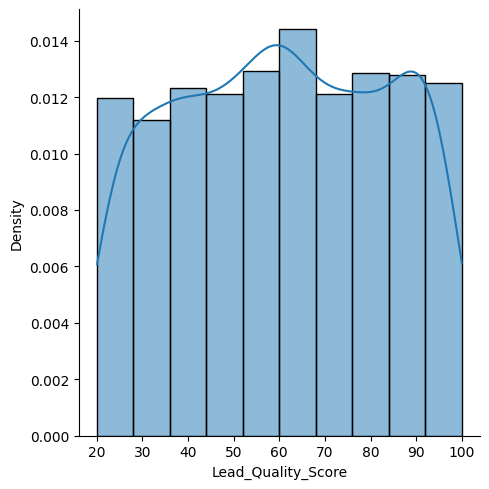

In [43]:
sns.displot(dataset["Lead_Quality_Score"],
            kde=True,
            stat="density",
            bins=10)

plt.show()

In [44]:
def get_pdf_probability(dataset,startrange,endrange): # Define a function that takes a dataset and a numeric range (start, end)
    
    from matplotlib import pyplot
    from scipy.stats import norm
    import seaborn as sns
    # Import libraries for plotting and statistical distribution
    
    ax = sns.distplot(dataset,kde=True,kde_kws={'color':'blue'},color='Green')
    # Plot the dataset as a histogram (green) with a KDE(Kernel Density Estimation) curve (blue)
    
    pyplot.axvline(startrange,color='Red')
    pyplot.axvline(endrange,color='Red')
    # Draw vertical red lines at the start and end range values (red)
    
    sample = dataset
    # Assign dataset to a variable called sample (redundant but clear)
    
    sample_mean =sample.mean()
    sample_std = sample.std()
    # Calculate mean and standard deviation of the dataset
    
    print('Mean=%.3f, Standard Deviation=%.3f' % (sample_mean, sample_std))
    # Print mean and standard deviation with 3 decimal precision
    
    dist = norm(sample_mean, sample_std)
    # Create a normal distribution object with the dataset’s mean and std
    
    values = [value for value in range(startrange, endrange)]
    # Generate integer values between start and end range
    
    probabilities = [dist.pdf(value) for value in values]
    # Calculate the probability density (PDF) for each value in the range
    
    prob=sum(probabilities)
    # Sum all PDF values (approximate area, not exact probability)
    
    print("The area between range({},{}):{}".format(startrange,endrange,sum(probabilities)))
    # Print the summed PDF values for the given range
    
    return prob
    # Return the summed probability density

Mean=60.528, Standard Deviation=22.825
The area between range(40,60):0.3036024201507377


C:\Users\msdhi\AppData\Local\Temp\ipykernel_11680\625683821.py:8: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax = sns.distplot(dataset,kde=True,kde_kws={'color':'blue'},color='Green')


0.3036024201507377

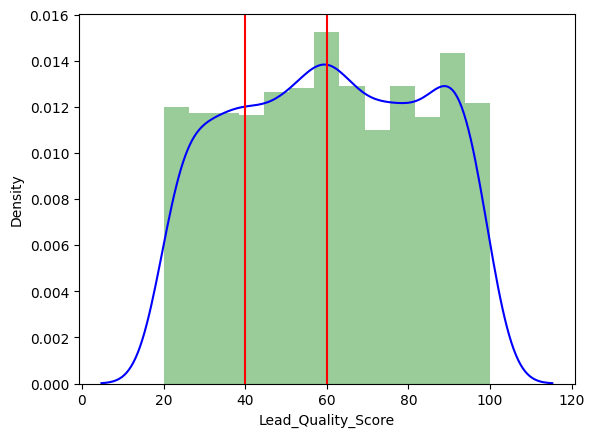

In [45]:
get_pdf_probability(dataset["Lead_Quality_Score"],40,60)

Mean=60.528, Standard Deviation=22.825
The area between range(40,40):0


C:\Users\msdhi\AppData\Local\Temp\ipykernel_11680\625683821.py:8: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax = sns.distplot(dataset,kde=True,kde_kws={'color':'blue'},color='Green')


0

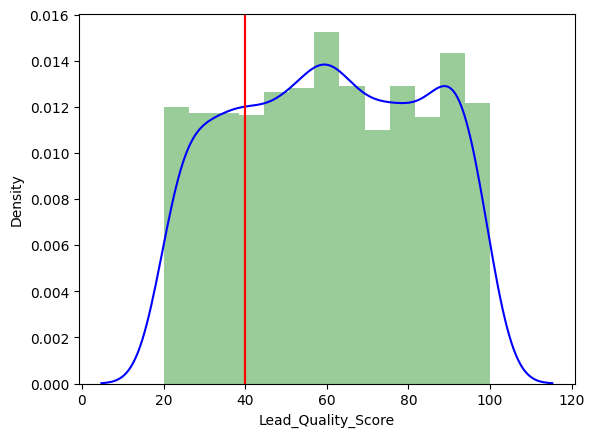

In [46]:
get_pdf_probability(dataset["Lead_Quality_Score"],40,40)# we don't have any value inbetween 40,40--> it means 0 output 

In [47]:
from statsmodels.distributions.empirical_distribution import ECDF
ecdf = ECDF(dataset['Lead_Quality_Score'])
ecdf(78) 

0.7245810055865921

In [48]:
def stdNBgraph(dataset):
        # Coverted to standard Normal Distribution
    import seaborn as sns
    mean=dataset.mean()
    std=dataset.std()

    values=[i for i in dataset]

    z_score=[((j-mean)/std) for j in values]

    sns.distplot(z_score,kde=True)

    sum(z_score)/len(z_score)
    #z_score.std()

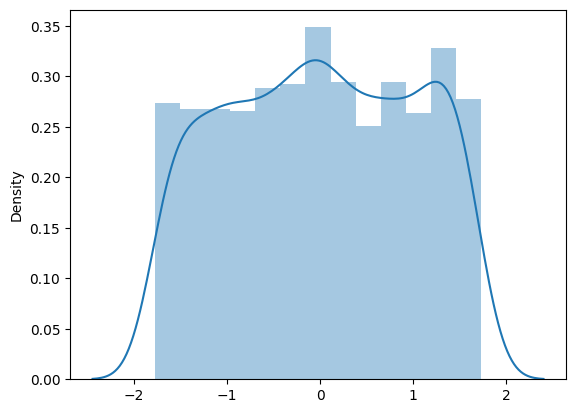

In [51]:
stdNBgraph(dataset["Lead_Quality_Score"])

In [50]:
import warnings
warnings.filterwarnings("ignore")

In [53]:
# Bivariant
dataset.select_dtypes(include="number").cov()

,Lead_ID,Total_Visits,Time_Spent_Website,Page_Views,Email_Opens,Email_Clicks,Previous_Interactions,Lead_Quality_Score,Age,Annual_Income,Sales_Calls,Days_Since_Last_Activity,Estimated_Lead_Value
Lead_ID,270078.531769,156.969940,-6.614870e+03,-53.114699,38.657286,-21.238046,-1.530604,-198.701900,-71.559938,3.017733e+05,-94.152170,-398.168720,-2.027819e+05
Total_Visits,156.969940,73.471225,2.058832e+01,-0.668044,1.365745,0.371522,-1.271395,-0.509368,6.526376,5.226646e+03,-0.339286,-1.287599,4.860718e+04
Time_Spent_Website,-6614.870191,20.588319,1.753825e+05,-69.594782,-37.261562,30.906320,-45.310126,346.183895,13.022784,-9.204794e+05,-30.366642,243.502535,3.269780e+06
Page_Views,-53.114699,-0.668044,-6.959478e+01,29.961161,0.234177,-0.428814,-0.216116,-2.072019,2.096467,-1.253477e+03,0.104735,-1.482048,-4.294427e+03
Email_Opens,38.657286,1.365745,-3.726156e+01,0.234177,35.657735,-0.609970,0.731144,-0.191586,2.391471,-5.315393e+03,-1.004925,-2.638471,-3.482736e+03
Email_Clicks,-21.238046,0.371522,3.090632e+01,-0.428814,-0.609970,9.678015,0.057093,1.277041,-0.324064,-7.798281e+02,0.147479,5.809260,9.266138e+03
Previous_Interactions,-1.530604,-1.271395,-4.531013e+01,-0.216116,0.731144,0.057093,21.391471,-1.013208,0.991253,-1.006477e+04,0.246007,-1.407446,2.179468e+04
Lead_Quality_Score,-198.701900,-0.509368,3.461839e+02,-2.072019,-0.191586,1.277041,-1.013208,520.983594,4.644216,-3.414964e+04,0.309863,-5.829845,3.658326e+05
Age,-71.559938,6.526376,1.302278e+01,2.096467,2.391471,-0.324064,0.991253,4.644216,133.457786,2.143247e+04,1.770355,4.219897,1.146054e+04
Annual_Income,301773.276937,5226.645687,-9.204794e+05,-1253.476638,-5315.393175,-779.828104,-10064.772583,-34149.637102,21432.467033,1.287275e+09,-3504.248910,23760.039249,1.033389e+08


In [54]:
dataset.select_dtypes(include="number").corr()

,Lead_ID,Total_Visits,Time_Spent_Website,Page_Views,Email_Opens,Email_Clicks,Previous_Interactions,Lead_Quality_Score,Age,Annual_Income,Sales_Calls,Days_Since_Last_Activity,Estimated_Lead_Value
Lead_ID,1.000000,0.035238,-0.030394,-0.018672,0.012457,-0.013136,-0.000637,-0.016751,-0.011919,0.016185,-0.038826,-0.014860,-0.017991
Total_Visits,0.035238,1.000000,0.005735,-0.014239,0.026683,0.013933,-0.032070,-0.002604,0.065909,0.016995,-0.008483,-0.002914,0.261466
Time_Spent_Website,-0.030394,0.005735,1.000000,-0.030360,-0.014900,0.023723,-0.023393,0.036216,0.002692,-0.061261,-0.015540,0.011278,0.359997
Page_Views,-0.018672,-0.014239,-0.030360,1.000000,0.007165,-0.025182,-0.008537,-0.016585,0.033154,-0.006383,0.004101,-0.005252,-0.036174
Email_Opens,0.012457,0.026683,-0.014900,0.007165,1.000000,-0.032835,0.026473,-0.001406,0.034667,-0.024810,-0.036066,-0.008570,-0.026892
Email_Clicks,-0.013136,0.013933,0.023723,-0.025182,-0.032835,1.000000,0.003968,0.017985,-0.009017,-0.006987,0.010160,0.036219,0.137334
Previous_Interactions,-0.000637,-0.032070,-0.023393,-0.008537,0.026473,0.003968,1.000000,-0.009598,0.018552,-0.060652,0.011399,-0.005902,0.217272
Lead_Quality_Score,-0.016751,-0.002604,0.036216,-0.016585,-0.001406,0.017985,-0.009598,1.000000,0.017613,-0.041700,0.002909,-0.004954,0.738998
Age,-0.011919,0.065909,0.002692,0.033154,0.034667,-0.009017,0.018552,0.017613,1.000000,0.051709,0.032842,0.007085,0.045741
Annual_Income,0.016185,0.016995,-0.061261,-0.006383,-0.024810,-0.006987,-0.060652,-0.041700,0.051709,1.000000,-0.020931,0.012845,0.132801


In [55]:
from statsmodels.stats.outliers_influence import variance_inflation_factor # his line imports the function variance_inflation_factor from statsmodels.It is used to calculate VIF, which checks if your input features are highly correlated (multicollinearity)
def calc_vif(X): # we define a function called calc_vif.It takes X (your dataset with input features) as input
    vif = pd.DataFrame() # Create an empty DataFrame called vif.We will store results (feature names + their VIF values) inside this
    vif["variables"] = X.columns # Add a column named "variables" in the DataFrame.This column will contain the names of all features (columns of X)
    vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]  # For each feature (looping through all columns using range(X.shape[1])):X.values gives the raw numeric values of your dataset. variance_inflation_factor(..., i) calculates the VIF for the i-th column.The result is stored in a new column "VIF"

    return(vif) # Finally, the function returns the DataFrame with two columns:"variables" → feature names"VIF" → VIF values for each feature

In [56]:
calc_vif(dataset[["Lead_Quality_Score","Email_Opens"]])

,variables,VIF
0,Lead_Quality_Score,2.806144
1,Email_Opens,2.806144
